# Food Spoilage Prediction – Machine Learning Project


### Research Question

> **Can machine learning predict whether a food product will spoil using product, storage, handling, demand and supply-chain information?**

### Target Variable

`was_spoiled`

- `0` = Unlikely to Spoil
- `1` = Likely to Spoil


# DATA COLLECTION

## 1.1 Import Pandas

In [89]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt

## 1.2 Load the Dataset

Dataset is from the Kaggle its a synthetic dataset. 


In [90]:
file_path = 'perishable_cleaned_balanced.csv'

df = pd.read_csv(file_path)

print("Dataset loaded successfully.")

Dataset loaded successfully.


## 1.3 Check Dataset Size

In [91]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 38884
Number of columns: 42


## 1.4 View the First Rows

In [92]:
df.head()

,record_id,product_id,product_name,category,store_id,region,supplier_id,transaction_date,expiration_date,shelf_life_days,...,selling_price,units_sold,units_wasted,waste_pct,revenue,waste_cost,profit,profit_margin_pct,supplier_score,is_promoted
0,68208,BEV_MIL_895,Milk Alternatives,Beverages,STORE_044,Northeast,SUPPLIER_11,2024-11-15,2024-12-12,30,...,9.75,0,55,100.0,0.00,305.25,-305.25,0.0,6,1
1,10766,BEV_MIL_974,Milk Alternatives,Beverages,STORE_030,Southwest,SUPPLIER_17,2024-01-26,2024-02-09,14,...,2.52,129,56,30.3,325.08,57.68,134.53,41.4,9,1
2,52293,REA_SOU_940,Soups,Ready_to_Eat,STORE_045,Southwest,SUPPLIER_12,2024-12-23,2024-12-24,1,...,3.99,269,116,30.1,1073.31,982.52,-2187.64,-203.8,6,0
3,88623,DAI_BUT_775,Butter,Dairy,STORE_018,West,SUPPLIER_01,2024-09-07,2024-09-16,9,...,7.57,239,103,30.1,1809.23,473.80,236.03,13.0,7,0
4,79413,PHA_ANT_747,Antibiotics,Pharmaceuticals,STORE_005,Southeast,SUPPLIER_04,2024-02-03,2024-10-03,262,...,331.06,0,17,100.0,0.00,3259.07,-3259.07,0.0,9,0


## 1.5 View All Column Names

In [93]:
print(df.columns.tolist())

['record_id', 'product_id', 'product_name', 'category', 'store_id', 'region', 'supplier_id', 'transaction_date', 'expiration_date', 'shelf_life_days', 'days_remaining_at_purchase', 'storage_temp', 'temp_deviation', 'base_price', 'cost_price', 'initial_quantity', 'spoilage_sensitivity', 'day_of_week', 'is_weekend', 'month', 'daily_demand', 'demand_variability', 'temp_abuse_events', 'distribution_hours', 'handling_score', 'packaging_score', 'spoilage_risk', 'was_spoiled', 'quality_grade', 'days_until_expiry', 'markdown_applied', 'discount_pct', 'selling_price', 'units_sold', 'units_wasted', 'waste_pct', 'revenue', 'waste_cost', 'profit', 'profit_margin_pct', 'supplier_score', 'is_promoted']


## 1.6 Check Data Types

In [94]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38884 entries, 0 to 38883
Data columns (total 42 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   record_id                   38884 non-null  int64  
 1   product_id                  38884 non-null  object 
 2   product_name                38884 non-null  object 
 3   category                    38884 non-null  object 
 4   store_id                    38884 non-null  object 
 5   region                      38884 non-null  object 
 6   supplier_id                 38884 non-null  object 
 7   transaction_date            38884 non-null  object 
 8   expiration_date             38884 non-null  object 
 9   shelf_life_days             38884 non-null  int64  
 10  days_remaining_at_purchase  38884 non-null  int64  
 11  storage_temp                38884 non-null  float64
 12  temp_deviation              38884 non-null  float64
 13  base_price                  388

## 1.7 Check the Target Variable

Our target is `was_spoiled`.

This is a **binary classification** problem because there are two possible outcomes:

- `0` = Unlikely to Spoil
- `1` = Likely to Spoil


In [95]:
print(df['was_spoiled'].value_counts())

was_spoiled
0    19442
1    19442
Name: count, dtype: int64


## 1.8 Initial Feature Selection


### Main features

`category`
`region`
`shelf_life_days`
`days_remaining_at_purchase`
`storage_temp`
`temp_deviation`
`initial_quantity`
`spoilage_sensitivity`
`daily_demand`
`demand_variability`
`temp_abuse_events`
`distribution_hours`
`handling_score`
`packaging_score`
`supplier_score`

### Target

`was_spoiled`


# DATA CLEANING & EDA


## 2.1 Check Missing Values

In [96]:
missing = df.isnull().sum()

print(missing[missing > 0])

print("\nTotal missing values:", df.isnull().sum().sum())

Series([], dtype: int64)

Total missing values: 0


## 2.2 Check Duplicate Rows

In [97]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


## 2.3 Remove Exact Duplicates

In [98]:
df = df.drop_duplicates()

print("New dataset shape:", df.shape)

New dataset shape: (38884, 42)


## 2.4 Basic Statistics

In [99]:
df.describe()

,record_id,shelf_life_days,days_remaining_at_purchase,storage_temp,temp_deviation,base_price,cost_price,initial_quantity,spoilage_sensitivity,day_of_week,...,selling_price,units_sold,units_wasted,waste_pct,revenue,waste_cost,profit,profit_margin_pct,supplier_score,is_promoted
count,38884.000000,38884.000000,38884.000000,38884.000000,38884.000000,38884.000000,38884.000000,38884.000000,38884.000000,38884.000000,...,38884.000000,38884.000000,38884.000000,38884.000000,38884.000000,38884.000000,38884.000000,38884.000000,38884.000000,38884.000000
mean,50084.461604,66.815863,55.713250,3.124300,1.638774,37.251379,20.533892,254.807582,0.692240,3.009464,...,35.014886,187.600761,67.206820,28.383248,5545.505140,1923.052482,337.563476,6.765230,8.207077,0.149316
std,28883.504480,140.233850,117.639708,9.375791,1.224085,88.196659,49.375107,141.654210,0.214487,1.996799,...,85.911597,128.526562,77.451229,26.554576,18029.019243,8340.444787,10373.944923,48.133105,1.399503,0.356404
min,5.000000,1.000000,0.000000,-26.900000,0.000000,1.010000,0.410000,10.000000,0.300000,0.000000,...,0.340000,0.000000,0.000000,0.000000,0.000000,0.000000,-166388.160000,-1490.200000,6.000000,0.000000
25%,25140.500000,5.000000,4.000000,1.100000,0.700000,6.350000,3.410000,133.000000,0.500000,1.000000,...,5.320000,79.000000,0.000000,0.000000,513.070000,0.000000,-95.242500,0.000000,7.000000,0.000000
50%,49988.500000,9.000000,7.000000,3.900000,1.400000,10.400000,5.670000,254.000000,0.750000,3.000000,...,8.865000,179.000000,48.000000,30.100000,1359.705000,215.635000,166.940000,16.800000,9.000000,0.000000
75%,75087.500000,24.000000,20.000000,6.600000,2.400000,17.290000,9.700000,377.000000,0.900000,5.000000,...,15.690000,283.000000,107.000000,31.200000,2975.595000,664.370000,735.900000,35.700000,9.000000,0.000000
max,100000.000000,730.000000,720.000000,27.200000,8.900000,499.800000,346.060000,500.000000,0.950000,6.000000,...,499.800000,500.000000,500.000000,100.000000,236062.400000,166388.160000,119976.480000,60.100000,10.000000,1.000000


## 2.5 Check the Target Distribution

was_spoiled
0    19442
1    19442
Name: count, dtype: int64


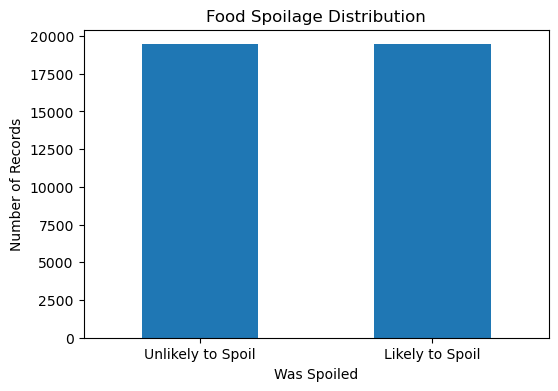

In [100]:
target_counts = df['was_spoiled'].value_counts()

print(target_counts)

target_counts.plot(
    kind='bar',
    figsize=(6, 4)
)

plt.title('Food Spoilage Distribution')
plt.xlabel('Was Spoiled')
plt.ylabel('Number of Records')
plt.xticks([0, 1], ['Unlikely to Spoil', 'Likely to Spoil'], rotation=0)
plt.show()

## 2.6 Target Percentages

In [101]:
target_percent = df['was_spoiled'].value_counts(normalize=True) * 100

print(target_percent)

was_spoiled
0    50.0
1    50.0
Name: proportion, dtype: float64


## 2.7 Explore Storage Temperature

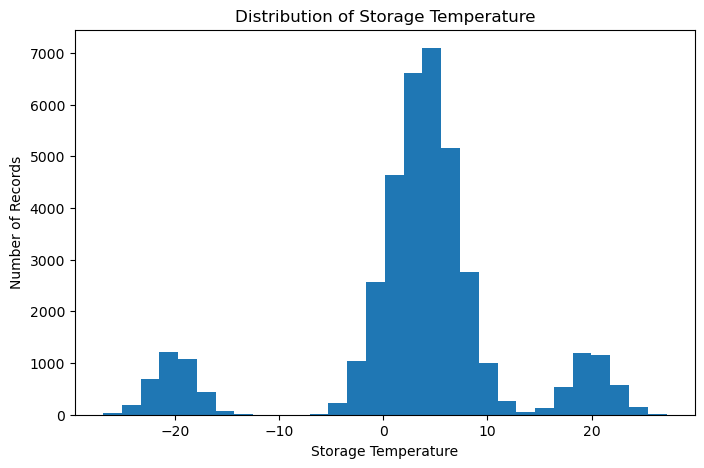

In [102]:
plt.figure(figsize=(8, 5))

plt.hist(df['storage_temp'].dropna(), bins=30)

plt.title('Distribution of Storage Temperature')
plt.xlabel('Storage Temperature')
plt.ylabel('Number of Records')

plt.show()

## 2.8 Explore Shelf Life

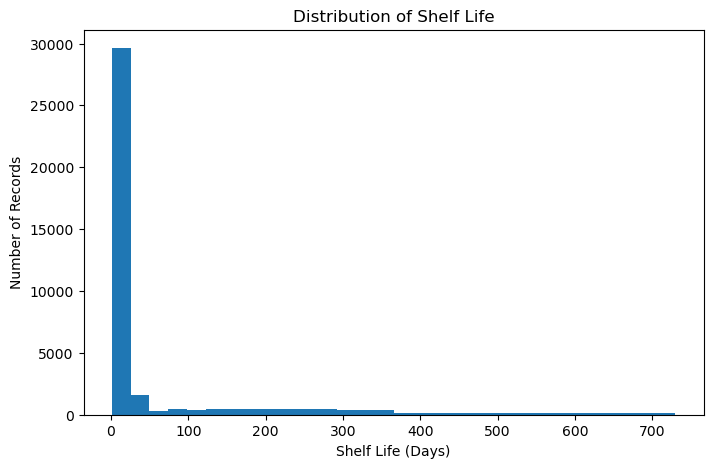

In [103]:
plt.figure(figsize=(8, 5))

plt.hist(df['shelf_life_days'].dropna(), bins=30)

plt.title('Distribution of Shelf Life')
plt.xlabel('Shelf Life (Days)')
plt.ylabel('Number of Records')

plt.show()

## 2.9 Spoilage by Food Category

In [104]:
category_spoilage = pd.crosstab(
    df['category'],
    df['was_spoiled'],
    normalize='index'
) * 100

print(category_spoilage)

was_spoiled              0          1
category                             
Bakery           51.196809  48.803191
Beverages        52.231900  47.768100
Dairy            51.268773  48.731227
Deli             49.896694  50.103306
Frozen_Meals     54.872483  45.127517
Meat             47.508719  52.491281
Pharmaceuticals  48.233259  51.766741
Produce          51.202300  48.797700
Ready_to_Eat     45.645793  54.354207
Seafood          48.754980  51.245020


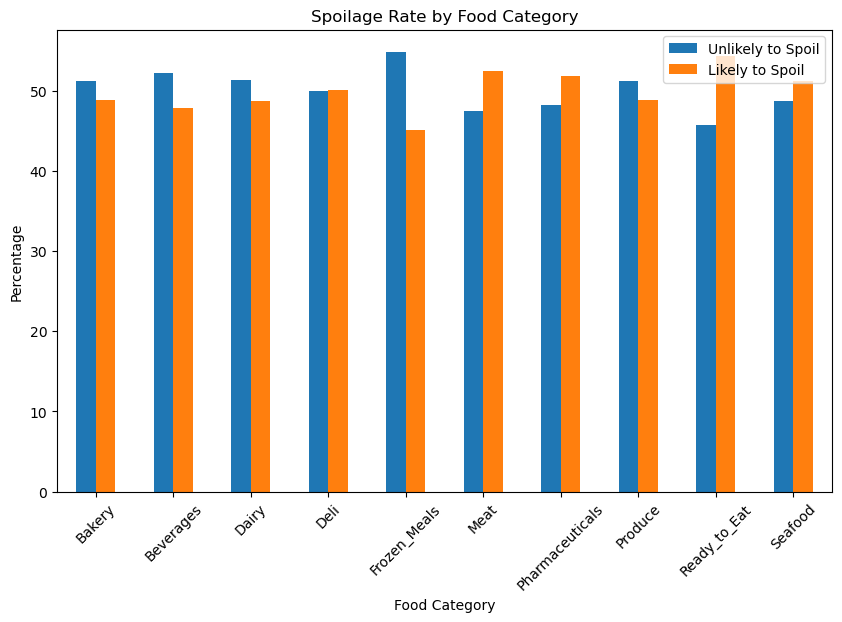

In [105]:
category_spoilage.plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title('Spoilage Rate by Food Category')
plt.xlabel('Food Category')
plt.ylabel('Percentage')
plt.xticks(rotation=45)
plt.legend(['Unlikely to Spoil', 'Likely to Spoil'])
plt.show()

## 2.10 Simple Correlation Check


In [106]:
numeric_columns = [
    'shelf_life_days',
    'days_remaining_at_purchase',
    'storage_temp',
    'temp_deviation',
    'initial_quantity',
    'spoilage_sensitivity',
    'daily_demand',
    'demand_variability',
    'temp_abuse_events',
    'distribution_hours',
    'handling_score',
    'packaging_score',
    'supplier_score',
    'was_spoiled'
]

correlation = df[numeric_columns].corr()

correlation['was_spoiled'].sort_values(ascending=False)

was_spoiled                   1.000000
temp_deviation                0.051817
spoilage_sensitivity          0.045522
temp_abuse_events             0.033415
distribution_hours            0.029005
daily_demand                  0.028827
storage_temp                  0.018018
supplier_score                0.006395
demand_variability            0.004955
shelf_life_days              -0.002007
days_remaining_at_purchase   -0.003910
initial_quantity             -0.005853
handling_score               -0.075220
packaging_score              -0.110950
Name: was_spoiled, dtype: float64

# FEATURE ENGINEERING

## 3.1 Select the Final Features

In [107]:
print("Statistical Summary")
df[numeric_columns].describe().T

Statistical Summary


,count,mean,std,min,25%,50%,75%,max
shelf_life_days,38884.0,66.815863,140.233850,1.0,5.0,9.00,24.0,730.00
days_remaining_at_purchase,38884.0,55.713250,117.639708,0.0,4.0,7.00,20.0,720.00
storage_temp,38884.0,3.124300,9.375791,-26.9,1.1,3.90,6.6,27.20
temp_deviation,38884.0,1.638774,1.224085,0.0,0.7,1.40,2.4,8.90
initial_quantity,38884.0,254.807582,141.654210,10.0,133.0,254.00,377.0,500.00
spoilage_sensitivity,38884.0,0.692240,0.214487,0.3,0.5,0.75,0.9,0.95
daily_demand,38884.0,66.030347,95.982872,0.0,6.0,33.00,87.0,1073.00
demand_variability,38884.0,0.300925,0.115379,0.1,0.2,0.30,0.4,0.50
temp_abuse_events,38884.0,0.827615,1.099826,0.0,0.0,0.00,1.0,8.00
distribution_hours,38884.0,38.600808,19.602082,4.0,21.8,38.80,55.6,72.00


In [108]:
corr = df[numeric_columns].corr()

In [109]:
features = [
    'category',
    'region',
    'shelf_life_days',
    'days_remaining_at_purchase',
    'storage_temp',
    'temp_deviation',
    'initial_quantity',
    'spoilage_sensitivity',
    'daily_demand',
    'demand_variability',
    'temp_abuse_events',
    'distribution_hours',
    'handling_score',
    'packaging_score',
    'supplier_score'
]

target = 'was_spoiled'

X = df[features].copy()
y = df[target].copy()

print("Number of features:", len(features))
print("X shape:", X.shape)
print("y shape:", y.shape)

Number of features: 15
X shape: (38884, 15)
y shape: (38884,)


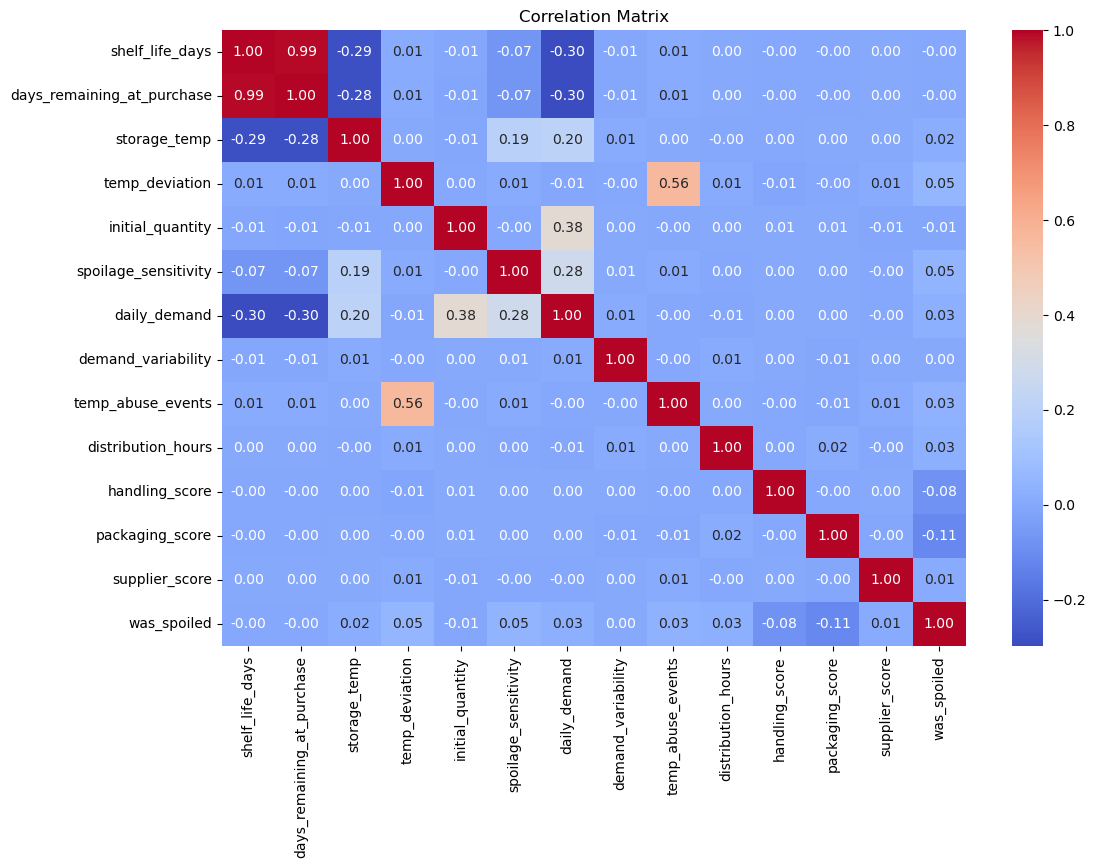

In [110]:
import seaborn as sns
plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)
plt.title("Correlation Matrix")
plt.show()

## 3.2 Create a Simple Temperature Risk Feature


In [111]:
X['temperature_problem'] = (
    X['temp_deviation'] > 0
).astype(int)

print(X[['temp_deviation', 'temperature_problem']].head())

   temp_deviation  temperature_problem
0             1.0                    1
1             1.9                    1
2             2.0                    1
3             2.3                    1
4             0.3                    1


## 3.3 Create a Simple Demand Pressure Feature


In [112]:
X['inventory_days_estimate'] = (
    X['initial_quantity'] /
    X['daily_demand'].replace(0, np.nan)
)

X['inventory_days_estimate'] = X['inventory_days_estimate'].fillna(0)

print(X[['initial_quantity', 'daily_demand', 'inventory_days_estimate']].head())

   initial_quantity  daily_demand  inventory_days_estimate
0                55             0                 0.000000
1               185            20                 9.250000
2               385           522                 0.737548
3               342            62                 5.516129
4                17             0                 0.000000


## 3.4 Update the Numerical Feature List


In [113]:
categorical_features = [
    'category',
    'region'
]

numerical_features = [
    'shelf_life_days',
    'days_remaining_at_purchase',
    'storage_temp',
    'temp_deviation',
    'initial_quantity',
    'spoilage_sensitivity',
    'daily_demand',
    'demand_variability',
    'temp_abuse_events',
    'distribution_hours',
    'handling_score',
    'packaging_score',
    'supplier_score',
    'temperature_problem',
    'inventory_days_estimate'
]

print("Categorical features:", categorical_features)
print("Number of numerical features:", len(numerical_features))

Categorical features: ['category', 'region']
Number of numerical features: 15


## 3.5 Check the Final Dataset

In [114]:
print("Final X shape:", X.shape)
print("Final y shape:", y.shape)

X.head()

Final X shape: (38884, 17)
Final y shape: (38884,)


,category,region,shelf_life_days,days_remaining_at_purchase,storage_temp,temp_deviation,initial_quantity,spoilage_sensitivity,daily_demand,demand_variability,temp_abuse_events,distribution_hours,handling_score,packaging_score,supplier_score,temperature_problem,inventory_days_estimate
0,Beverages,Northeast,30,27,4.0,1.0,55,0.40,0,0.48,1,71.7,9,6,6,1,0.000000
1,Beverages,Southwest,14,14,6.9,1.9,185,0.40,20,0.15,0,13.2,6,7,9,1,9.250000
2,Ready_to_Eat,Southwest,1,1,6.0,2.0,385,0.90,522,0.31,1,63.1,4,5,6,1,0.737548
3,Dairy,West,9,9,6.3,2.3,342,0.70,62,0.16,0,27.9,10,6,7,1,5.516129
4,Pharmaceuticals,Southeast,262,243,5.3,0.3,17,0.85,0,0.35,0,24.2,4,8,9,1,0.000000


# MODELING


## 4.1 Import Machine Learning Libraries

In [115]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

## 4.2 Split the Data


In [116]:
from sklearn.model_selection import train_test_split

# 60% training and 40% temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.40,
    random_state=42,
    stratify=y
)

# Divide temporary data equally:
# 20% validation and 20% test
X_validation, X_test, y_validation, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Training data:", X_train.shape, y_train.shape)
print("Validation data:", X_validation.shape, y_validation.shape)
print("Test data:", X_test.shape, y_test.shape)

print("\nTraining percentage:", len(X_train) / len(X) * 100)
print("Validation percentage:", len(X_validation) / len(X) * 100)
print("Test percentage:", len(X_test) / len(X) * 100)

Training data: (23330, 17) (23330,)
Validation data: (7777, 17) (7777,)
Test data: (7777, 17) (7777,)

Training percentage: 59.99897129924905
Validation percentage: 20.000514350375475
Test percentage: 20.000514350375475


## 4.3 Preprocess the Features


In [117]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            'numeric',
            StandardScaler(),
            numerical_features
        ),
        (
            'categorical',
            OneHotEncoder(handle_unknown='ignore'),
            categorical_features
        )
    ]
)

print("Preprocessor created.")

Preprocessor created.


In [118]:
from sklearn.dummy import DummyClassifier

baseline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DummyClassifier(strategy="most_frequent"))
])

baseline.fit(X_train, y_train)

baseline_pred = baseline.predict(X_test)

## 4.4 Model 1 – Logistic Regression


In [119]:
logistic_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', LogisticRegression(
            max_iter=1000,
            class_weight='balanced'
        ))
    ]
)

logistic_model.fit(X_train, y_train)

print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


## 4.5 Make Logistic Regression Predictions

In [120]:
logistic_predictions = logistic_model.predict(X_test)

print("Predictions completed.")

Predictions completed.


## 4.6 Model 2 – Random Forest


In [121]:
random_forest_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            class_weight='balanced',
            n_jobs=-1
        ))
    ]
)

random_forest_model.fit(X_train, y_train)

print("Random Forest trained successfully.")

Random Forest trained successfully.


## 4.7 Make Random Forest Predictions

In [122]:
rf_predictions = random_forest_model.predict(X_test)

print("Predictions completed.")

Predictions completed.


# EVALUATION


## 5.1 Import Evaluation Metrics

In [123]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

## 5.2 Evaluate Logistic Regression

In [124]:
logistic_accuracy = accuracy_score(y_test, logistic_predictions)
logistic_precision = precision_score(y_test, logistic_predictions)
logistic_recall = recall_score(y_test, logistic_predictions)
logistic_f1 = f1_score(y_test, logistic_predictions)

print("Logistic Regression")
print("-------------------")
print("Accuracy :", logistic_accuracy)
print("Precision:", logistic_precision)
print("Recall   :", logistic_recall)
print("F1 Score :", logistic_f1)

print("\nClassification Report:")
print(classification_report(
    y_test,
    logistic_predictions,
    target_names=['Not Spoiled', 'Spoiled']
))

Logistic Regression
-------------------
Accuracy : 0.5673138742445674
Precision: 0.5665225133553803
Recall   : 0.5727880658436214
F1 Score : 0.5696380611331372

Classification Report:
              precision    recall  f1-score   support

 Not Spoiled       0.57      0.56      0.56      3889
     Spoiled       0.57      0.57      0.57      3888

    accuracy                           0.57      7777
   macro avg       0.57      0.57      0.57      7777
weighted avg       0.57      0.57      0.57      7777



## 5.3 Evaluate Random Forest

In [125]:
rf_accuracy = accuracy_score(y_test, rf_predictions)
rf_precision = precision_score(y_test, rf_predictions)
rf_recall = recall_score(y_test, rf_predictions)
rf_f1 = f1_score(y_test, rf_predictions)

print("Random Forest")
print("-------------")
print("Accuracy :", rf_accuracy)
print("Precision:", rf_precision)
print("Recall   :", rf_recall)
print("F1 Score :", rf_f1)

print("\nClassification Report:")
print(classification_report(
    y_test,
    rf_predictions,
    target_names=['Not Spoiled', 'Spoiled']
))

Random Forest
-------------
Accuracy : 0.5435257811495435
Precision: 0.5430244399185336
Recall   : 0.5486111111111112
F1 Score : 0.5458034800409417

Classification Report:
              precision    recall  f1-score   support

 Not Spoiled       0.54      0.54      0.54      3889
     Spoiled       0.54      0.55      0.55      3888

    accuracy                           0.54      7777
   macro avg       0.54      0.54      0.54      7777
weighted avg       0.54      0.54      0.54      7777



## 5.4 Compare Both Models

This table makes it easy to identify the better model.

In [126]:
results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest'
    ],
    'Accuracy': [
        logistic_accuracy,
        rf_accuracy
    ],
    'Precision': [
        logistic_precision,
        rf_precision
    ],
    'Recall': [
        logistic_recall,
        rf_recall
    ],
    'F1 Score': [
        logistic_f1,
        rf_f1
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.567314,0.566523,0.572788,0.569638
1,Random Forest,0.543526,0.543024,0.548611,0.545803


## 5.5 Confusion Matrix – Random Forest



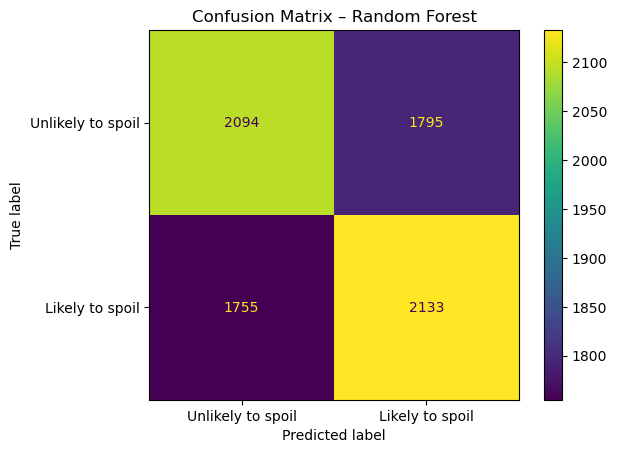

In [127]:
cm = confusion_matrix(y_test, rf_predictions)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Unlikely to spoil', 'Likely to spoil']
)

disp.plot()

plt.title('Confusion Matrix – Random Forest')
plt.show()

## 5.7 Feature Importance



In [128]:
rf_preprocessor = random_forest_model.named_steps['preprocessor']
rf_model = random_forest_model.named_steps['model']

feature_names = rf_preprocessor.get_feature_names_out()
importance = rf_model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
9,numeric__distribution_hours,0.100157
4,numeric__initial_quantity,0.095654
14,numeric__inventory_days_estimate,0.089136
2,numeric__storage_temp,0.085897
7,numeric__demand_variability,0.083627
3,numeric__temp_deviation,0.077798
6,numeric__daily_demand,0.077246
1,numeric__days_remaining_at_purchase,0.062364
0,numeric__shelf_life_days,0.061231
10,numeric__handling_score,0.043343


## 5.8 Plot the Most Important Features

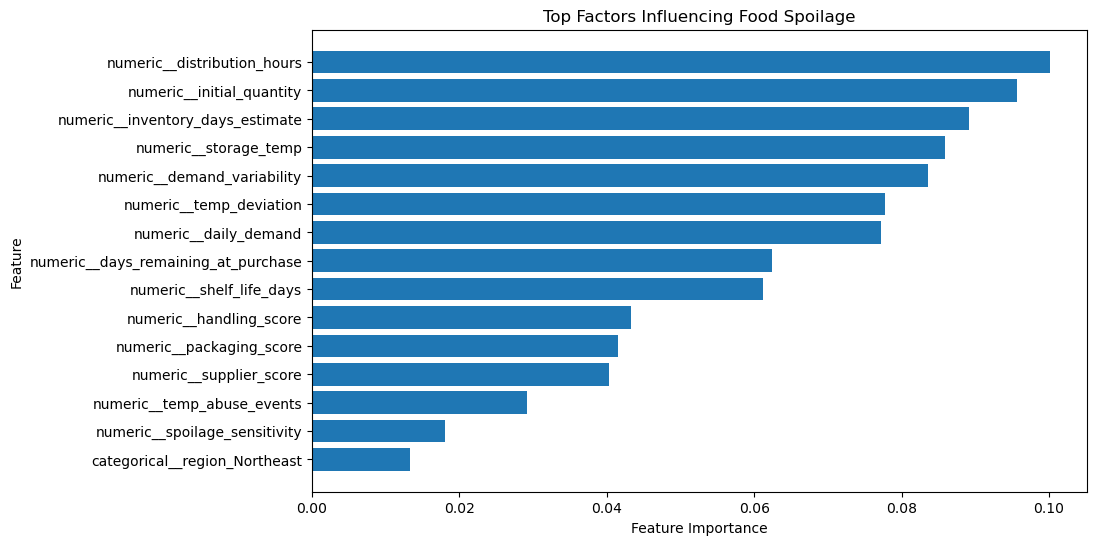

In [129]:
top_features = feature_importance.head(15)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features['Feature'][::-1],
    top_features['Importance'][::-1]
)

plt.title('Top Factors Influencing Food Spoilage')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')

plt.show()

## 5.9 Predict a New Food Product


In [130]:
new_food = pd.DataFrame({
    'category': ['Dairy'],
    'region': ['North'],
    'shelf_life_days': [30],
    'days_remaining_at_purchase': [5],
    'storage_temp': [8.0],
    'temp_deviation': [4.0],
    'initial_quantity': [200],
    'spoilage_sensitivity': [0.9],
    'daily_demand': [20],
    'demand_variability': [0.4],
    'temp_abuse_events': [3],
    'distribution_hours': [50],
    'handling_score': [4],
    'packaging_score': [5],
    'supplier_score': [6],
    'temperature_problem': [1],
    'inventory_days_estimate': [10]
})

new_food

,category,region,shelf_life_days,days_remaining_at_purchase,storage_temp,temp_deviation,initial_quantity,spoilage_sensitivity,daily_demand,demand_variability,temp_abuse_events,distribution_hours,handling_score,packaging_score,supplier_score,temperature_problem,inventory_days_estimate
0,Dairy,North,30,5,8.0,4.0,200,0.9,20,0.4,3,50,4,5,6,1,10


In [131]:
prediction = random_forest_model.predict(new_food)

if prediction[0] == 1:
    print("Prediction: FOOD IS LIKELY TO SPOIL")
else:
    print("Prediction: FOOD IS NOT LIKELY TO SPOIL")

Prediction: FOOD IS LIKELY TO SPOIL


In [132]:
probability = random_forest_model.predict_proba(new_food)

print("Probability of NOT spoiling:", round(probability[0][0], 3))
print("Probability of spoiling:", round(probability[0][1], 3))

Probability of NOT spoiling: 0.373
Probability of spoiling: 0.627
